In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

from b1.func import sigmoid, softmax, cee
from b1.func import num_grad as _num_grad

# SGD 최적화 
- 전체 경사 하강법은 연산이 너무 많음
    - GD $$W \leftarrow W- \eta\frac{\partial L}{\partial W}$$
- 배치 $B$ 샘플링을 통한 전체 경사 근사
    - SGD $$W \leftarrow W- \eta\frac{\partial L_B}{\partial W}$$
- 단점
    - 방향에 노이즈 존재 - 불안정
    - 비등방성에 취약

In [3]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

## 모멘텀
- 속도 업데이트
    - 이전 이동 방향이 다음 이동 방향을 결정하는데 영향을 줌
    - 모멘텀 계수 $\alpha$ 를 이용한 이전 속도 영향 조절/감쇄
    - SGD에 비해 변동성이 적음
- Momentum $$v \leftarrow \alpha v- \eta\frac{\partial L_B}{\partial W} \\ W \leftarrow W+v$$

In [4]:
class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key]
            params[key] += self.v[key]

## AdaGrad
- 적응형 학습률
- AdaGrad
    - $$h \leftarrow h + \frac{\partial L_B}{\partial W} \odot \frac{\partial L_B}{\partial W} \\ \; \\ W\leftarrow W- \eta\frac{1}{\sqrt{h}}\frac{\partial L_B}{\partial W}$$


In [5]:
class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for k, v in params.items():
                self.h[k] = np.zeros_like(v)

        for k in params.keys():
            self.h[k] += grads[k] * grads[k]
            params[k] -= self.lr * grads[k] / (np.sqrt(self.h[k]) + 1e-7)

## RMSProp
- 이동평균을 이용한 적응형 학습률
- adagrad 의 학습률 소실 문제 해결
- RMSProp
    - $$h \leftarrow \rho h + (1-\rho)\frac{\partial L_B}{\partial W} \odot \frac{\partial L_B}{\partial W} \\ \; \\ W\leftarrow W- \eta\frac{1}{\sqrt{h}+\epsilon}\frac{\partial L_B}{\partial W}$$


In [6]:
class RMSProp:
    def __init__(self, lr=0.01, rho=0.9, eps=1e-7):
        self.lr = lr
        self.rho = rho
        self.eps = eps
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for k, v in params.items():
                self.h[k] = np.zeros_like(v)

        for k in params.keys():
            self.h[k] = self.rho * self.h[k] + (1 - self.rho) * grads[k] * grads[k]
            params[k] -= self.lr * grads[k] / (np.sqrt(self.h[k]) + self.eps)

## Adam
- Momentum + RMSProp + bias correction
- Adam
    - 1차 모멘텀 $$m \leftarrow \beta_1 m + (1-\beta_1)\frac{\partial L_B}{\partial W} $$
    - 2차 모멘텀 $$v \leftarrow \beta_2 v + (1-\beta_2)\frac{\partial L_B}{\partial W} \odot \frac{\partial L_B}{\partial W} $$
    - 초기값 편향 보정 $$\hat m = \frac{m}{1-\beta_1^t} \;\;  v = \frac{v}{1-\beta_1^t}$$
    - 업데이트 $$W \leftarrow W-\alpha \frac{m}{\sqrt v +\epsilon}$$

In [7]:
class Adam:
    def __init__(self, lr=0.001, b1=0.9, b2=0.999, eps=1e-8):
        self.lr = lr
        self.b1 = b1
        self.b2 = b2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 1

    def update(self, params, grads):
        if self.m is None:
            self.m = {}
            for k, v in params.items():
                self.m[k] = np.zeros_like(v)

        if self.v is None:
            self.v = {}
            for k, v in params.items():
                self.v[k] = np.zeros_like(v)

        for k in params.keys():
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]            
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] * grads[k]

            m = self.m[k] / (1 - self.b1**self.t)
            v = self.v[k] / (1 - self.b2**self.t)

            params[k] -= self.lr * m / (np.sqrt(v) + self.eps)

        self.t += 1

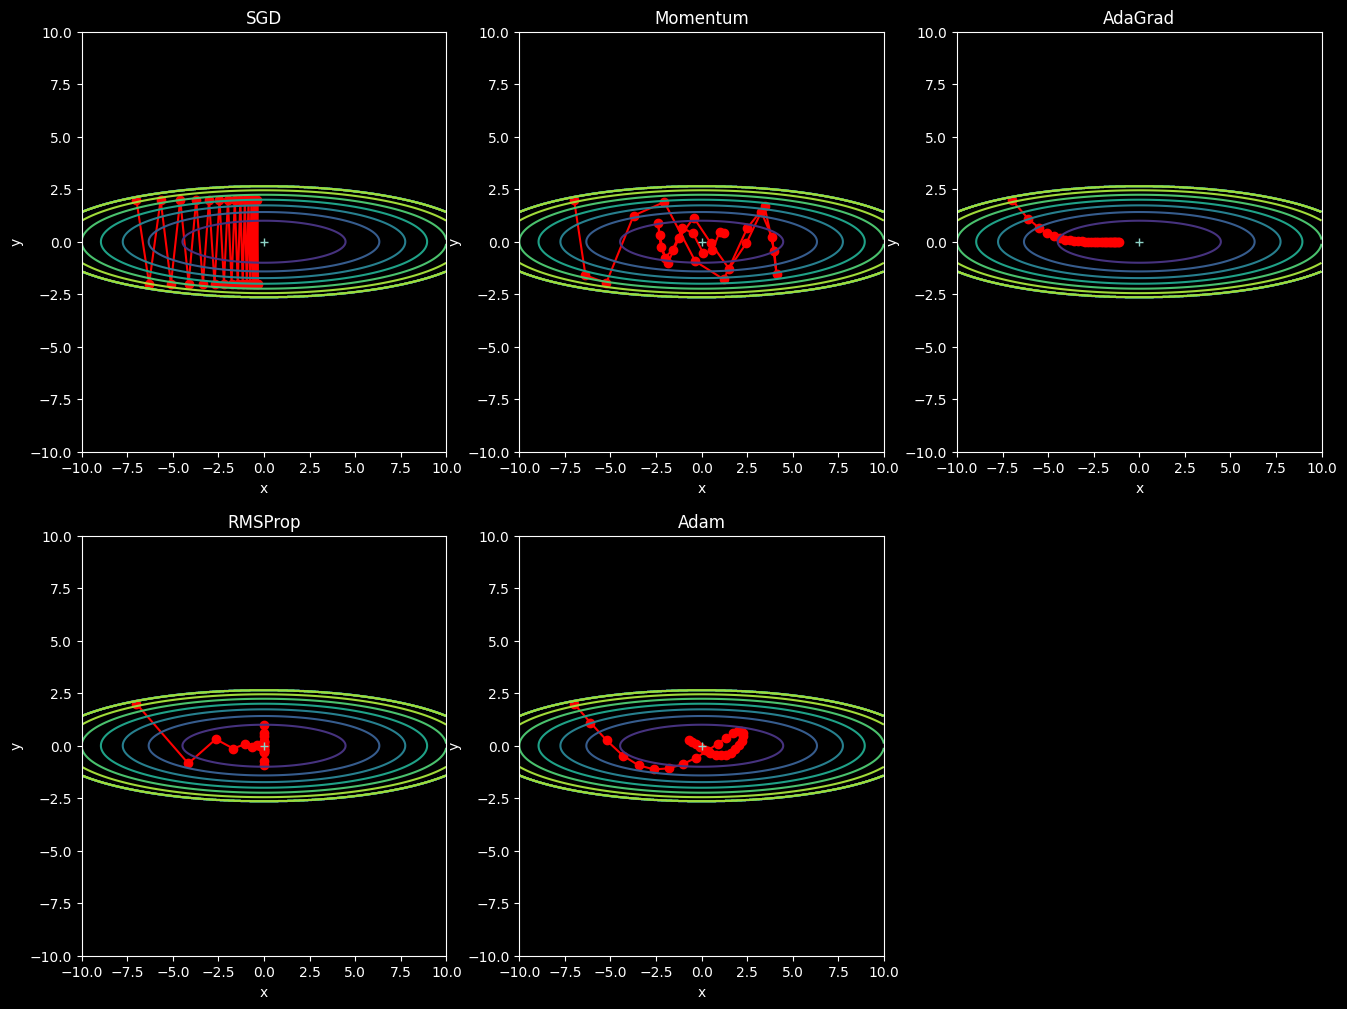

In [14]:
from collections import OrderedDict


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0 * y


init_pos = (-7.0, 2.0)
params = {}
params["x"], params["y"] = init_pos[0], init_pos[1]
grads = {}
grads["x"], grads["y"] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=1)
optimizers["Momentum"] = Momentum(lr=0.9)
optimizers["AdaGrad"] = AdaGrad(lr= 0.9)
optimizers["RMSProp"] = RMSProp(lr = 0.9)
optimizers["Adam"] = Adam(lr=0.9)

idx = 1

plt.figure(figsize=(16, 12))
for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params["x"], params["y"] = init_pos[0], init_pos[1]

    for i in range(30):
        x_history.append(params["x"])
        y_history.append(params["y"])

        grads["x"], grads["y"] = df(params["x"], params["y"])
        optimizer.update(params, grads)

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)

    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    # 외곽선 단순화
    mask = Z > 7
    Z[mask] = 0

    # 그래프 그리기
    plt.subplot(2, 3, idx)
    idx += 1
    plt.plot(x_history, y_history, "o-", color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, "+")
    # colorbar()
    # spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")



plt.show()

In [16]:
from tqdm import tqdm

from datasets.mnist import load_mnist
from b1.module.multi_layer_net import MultiLayerNet
from b1.utils.fuction import smooth_curve

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000

optimizers = {}
optimizers["SGD"] = SGD()
optimizers["Momentum"] = Momentum()
optimizers["AdaGrad"] = AdaGrad()
optimizers["RMSProp"] = RMSProp()
optimizers["Adam"] = Adam()

networks = {}
train_loss = {}
for k in optimizers.keys():
    networks[k] = MultiLayerNet(
        input_size=784, 
        hidden_size_list=[100, 100, 100, 100, 100], 
        output_size=10
    )
    train_loss[k] = []

pbar = tqdm(range(max_iterations))
for i in pbar:
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for k in optimizers.keys():
        grads = networks[k].gradient(x_batch, t_batch)
        optimizers[k].update(networks[k].params, grads)

        loss = networks[k].loss(x_batch, t_batch)
        train_loss[k].append(loss)

    if i % 100 == 0:
        loss_dict = {"iteration":str(i)}
        for k in optimizers.keys():
            loss = networks[k].loss(x_batch, t_batch)
            loss_dict[k] = f"{loss:.3f}"
        pbar.set_postfix(loss_dict)


markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "RMSProp":"*", "Adam": "D"}
x = np.arange(max_iterations)
for k in optimizers.keys():
    plt.plot(
        x, smooth_curve(train_loss[k]), marker=markers[k], markevery=100, label=k
    )
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()

  1%|          | 13/2000 [00:08<22:03,  1.50it/s, iteration=0, SGD=2.386, Momentum=2.342, AdaGrad=2.087, RMSProp=5.992, Adam=2.251]


KeyboardInterrupt: 